# Midterm Project: SRGAN for Retinal OCT Classification

In this notebook I load Model A from Assignment 1.

**Dataset:** Retinal OCT Images - Srinivasan (NORMAL, DME, DRUSEN)

I train an SRGAN to turn 32x32 OCT images into 128x128 images.
Then I train Model B on the SR images and compare it with Model A.

**Steps:**
1. Load Model A
2. Train the SRGAN
3. Train Model B on SR images
4. Compare Model A and Model B

Model A training code is in Assignment 1.

**Short names used here:**
- **SR / SRGAN** - super resolution / the GAN model
- **HR / LR** - 128x128 / 32x32
- **GAN** - generator and discriminator
- **gen / disc** - generator / discriminator
- **VGG** - pretrained feature model
- **MSE** - mean squared error
- **BCE** - binary cross entropy
- **cls / ds** - class / dataset

## Setup
Mount Drive and import libraries.

In [54]:
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image as PILImage

from sklearn.metrics import (f1_score, accuracy_score,
                             roc_auc_score, classification_report,
                             confusion_matrix)

# enable loading custom layers
keras.config.enable_unsafe_deserialization()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Paths

In [55]:
# paths
DATASET_PATH = "/content/drive/MyDrive/Srinivasan"
MODEL_A_PATH = "/content/drive/MyDrive/model_a.keras"
SAVE_DIR     = "/content/drive/MyDrive/midterm_checkpoints"

os.makedirs(SAVE_DIR, exist_ok=True)

# data settings
classes    = ["NORMAL", "DME", "DRUSEN"]
img_size   = (128, 128)
batch_size = 32

# image sizes
HR_SIZE = 128
LR_SIZE = 32

## Load Model A
Load the Assignment 1 model and test it.

In [56]:
# load Model A
model_a = tf.keras.models.load_model(MODEL_A_PATH)

# test generator
test_gen_maker = ImageDataGenerator(rescale=1./255)

test_gen = test_gen_maker.flow_from_directory(
    os.path.join(DATASET_PATH, "test"),
    target_size=img_size,
    batch_size=batch_size,
    classes=classes,
    class_mode="categorical",
    color_mode="rgb",
    shuffle=False
)

# predictions
y_true = test_gen.classes
probs_a = model_a.predict(test_gen)
y_pred_a = np.argmax(probs_a, axis=1)

# Model A results
print("Model A Results:")
print(classification_report(y_true, y_pred_a, target_names=classes))

Found 963 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 250ms/step
Model A Results:
              precision    recall  f1-score   support

      NORMAL       0.93      0.97      0.95       437
         DME       0.74      0.90      0.81       305
      DRUSEN       1.00      0.61      0.76       221

    accuracy                           0.87       963
   macro avg       0.89      0.83      0.84       963
weighted avg       0.89      0.87      0.86       963



## SRGAN Architecture
Build the generator and discriminator.
The generator turns 32x32 LR images into 128x128 images.

In [57]:
# custom layer for depth_to_space
class DepthToSpace(layers.Layer):
    def __init__(self, block_size, **kwargs):
        super().__init__(**kwargs)
        self.block_size = block_size
    def call(self, x):
        return tf.nn.depth_to_space(x, self.block_size)
    def get_config(self):
        return {**super().get_config(), "block_size": self.block_size}

# used for saved generator models
CUSTOM_OBJECTS = {"DepthToSpace": DepthToSpace}

# generator
# keep the SRGAN idea but use fewer blocks
def build_generator():
    inputs = layers.Input(shape=(LR_SIZE, LR_SIZE, 3))

    x = layers.Conv2D(64, 9, padding="same")(inputs)
    x = layers.PReLU(shared_axes=[1, 2])(x)

    skip = x

    # residual blocks
    for _ in range(8):
        res = layers.Conv2D(64, 3, padding="same")(x)
        res = layers.BatchNormalization()(res)
        res = layers.PReLU(shared_axes=[1, 2])(res)
        res = layers.Conv2D(64, 3, padding="same")(res)
        res = layers.BatchNormalization()(res)
        x = layers.Add()([x, res])

    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, skip])

    # upsample 32 -> 64 -> 128
    x = layers.Conv2D(256, 3, padding="same")(x)
    x = DepthToSpace(2)(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)

    x = layers.Conv2D(256, 3, padding="same")(x)
    x = DepthToSpace(2)(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)

    outputs = layers.Conv2D(3, 9, padding="same", activation="tanh")(x)

    return models.Model(inputs, outputs, name="generator")


# discriminator
def build_discriminator():
    inputs = layers.Input(shape=(HR_SIZE, HR_SIZE, 3))

    x = layers.Conv2D(64, 3, padding="same")(inputs)
    x = layers.LeakyReLU(0.2)(x)

    for filters, stride in [(64,2),(128,1),(128,2),(256,1),(256,2),(512,1),(512,2)]:
        x = layers.Conv2D(filters, 3, strides=stride, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return models.Model(inputs, outputs, name="discriminator")


generator     = build_generator()
discriminator = build_discriminator()

generator.summary()
discriminator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_116 (Conv2D) │ (None, 32, 32,    │     15,616 │ input_layer_20[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_44 (PReLU)  │ (None, 32, 32,    │         64 │ conv2d_116[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_117 (Conv2D) │ (None, 32, 32,    │     36,928 │ p_re_lu_44[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_117[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_45 (PReLU)  │ (None, 32, 32,    │         64 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_118 (Conv2D) │ (None, 32, 32,    │     36,928 │ p_re_lu_45[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_118[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_36 (Add)        │ (None, 32, 32,    │          0 │ p_re_lu_44[0][0], │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_119 (Conv2D) │ (None, 32, 32,    │     36,928 │ add_36[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_119[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_46 (PReLU)  │ (None, 32, 32,    │         64 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_120 (Conv2D) │ (None, 32, 32,    │     36,928 │ p_re_lu_46[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_120[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_37 (Add)        │ (None, 32, 32,    │          0 │ add_36[0][0],     │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_121 (Conv2D) │ (None, 32, 32,    │     36,928 │ add_37[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_121[0][0]

 Total params: 959,427 (3.66 MB)

 Trainable params: 957,251 (3.65 MB)

 Non-trainable params: 2,176 (8.50 KB)

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_137 (Conv2D)             │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_36 (LeakyReLU)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_138 (Conv2D)             │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_113         │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_37 (LeakyReLU)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_139 (Conv2D)             │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_114         │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_38 (LeakyReLU)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_140 (Conv2D)             │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_115         │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_39 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_141 (Conv2D)             │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_116         │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_40 (LeakyReLU)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_142 (Conv2D)             │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_117         │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_41 (LeakyReLU)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_143 (Conv2D)             │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_118         │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_42 (LeakyReLU)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_144 (Conv2D)             │ (None, 8, 8, 512)      │     2,359,80

 Total params: 38,249,281 (145.91 MB)

 Trainable params: 38,245,569 (145.90 MB)

 Non-trainable params: 3,712 (14.50 KB)

## SRGAN Training
Pretrain the generator, then train the full GAN.

In [58]:
# VGG19 feature model
vgg_base = tf.keras.applications.VGG19(include_top=False, weights="imagenet")
vgg_base.trainable = False  # use features only

feature_extractor = tf.keras.Model(
    inputs=vgg_base.input,
    outputs=vgg_base.get_layer("block5_conv4").output,
    name="vgg_features"
)

# content loss from VGG features
def vgg_content_loss(hr_imgs, sr_imgs):
    hr_vgg = (hr_imgs + 1.0) / 2.0 * 255.0  # VGG input range
    sr_vgg = (sr_imgs + 1.0) / 2.0 * 255.0
    hr_feats = feature_extractor(hr_vgg, training=False)
    sr_feats = feature_extractor(sr_vgg, training=False)
    return tf.reduce_mean(tf.square(hr_feats - sr_feats)) / (12.75 ** 2)

bce_loss = tf.keras.losses.BinaryCrossentropy()
mse_loss = tf.keras.losses.MeanSquaredError()

# optimizers from the paper
gen_optimizer  = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.9)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.9)

In [59]:
# build LR and HR pairs
# custom loader for both image sizes
def make_srgan_dataset(data_dir, batch_size):
    all_paths = []
    # collect every train image path
    for cls in classes:
        cls_dir = os.path.join(data_dir, cls)
        if not os.path.exists(cls_dir):
            print(f"WARNING: folder not found - {cls_dir}")
            continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff")):
                all_paths.append(os.path.join(cls_dir, fname))

    print(f"found {len(all_paths)} training images")
    if not all_paths:
        raise ValueError("no images found - check DATASET_PATH")

    # turn one path into LR and HR
    def load_pair(path):
        # PIL handles tif files
        def read_img(p):
            img = np.array(PILImage.open(p.numpy().decode("utf-8")).convert("RGB"))
            return img.astype(np.float32)
        img = tf.py_function(read_img, [path], tf.float32)
        img.set_shape([None, None, 3])
        hr  = tf.image.resize(img, [HR_SIZE, HR_SIZE]) / 127.5 - 1.0  # HR in [-1, 1]
        lr  = (tf.image.resize(hr, [LR_SIZE, LR_SIZE]) + 1.0) / 2.0   # LR in [0, 1]
        return lr, hr

    # make the tf.data pipeline
    ds = tf.data.Dataset.from_tensor_slices(all_paths)
    ds = ds.shuffle(len(all_paths))
    ds = ds.map(load_pair, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_dataset = make_srgan_dataset(os.path.join(DATASET_PATH, "train"), batch_size)

# resume pretrain if checkpoints exist
pretrain_ckpts = sorted(glob.glob(os.path.join(SAVE_DIR, "gen_pretrain_*.keras")))

if pretrain_ckpts:
    latest = pretrain_ckpts[-1]
    done   = int(os.path.basename(latest).replace("gen_pretrain_", "").replace(".keras", ""))
    start_pretrain = done + 1
    generator = tf.keras.models.load_model(latest, custom_objects=CUSTOM_OBJECTS)
    print(f"resuming pretrain from epoch {start_pretrain} (loaded epoch {done})")
else:
    start_pretrain = 1
    print("starting pretrain from scratch")

# pretrain generator with MSE
if start_pretrain <= 10:
    print("phase 1: generator pretrain...")
    pretrain_opt = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.9)
    for epoch in range(start_pretrain, 11):
        losses = []
        for lr_batch, hr_batch in train_dataset:
            with tf.GradientTape() as tape:
                sr_batch = generator(lr_batch, training=True)
                loss     = mse_loss(hr_batch, sr_batch)
            grads = tape.gradient(loss, generator.trainable_variables)
            pretrain_opt.apply_gradients(zip(grads, generator.trainable_variables))
            losses.append(float(loss))
        print(f"pretrain epoch {epoch}/10 - loss: {np.mean(losses):.4f}")
        generator.save(os.path.join(SAVE_DIR, f"gen_pretrain_{epoch:02d}.keras"))
    print("pretrain done")
else:
    print("pretrain already complete, skipping")

found 2268 training images
resuming pretrain from epoch 11 (loaded epoch 10)
pretrain already complete, skipping


In [60]:
# train generator and discriminator together
# update disc, then gen
def train_step(lr_imgs, hr_imgs):
    # discriminator step
    fake_hr = generator(lr_imgs, training=False)
    with tf.GradientTape() as disc_tape:
        real_out = discriminator(hr_imgs, training=True)
        fake_out = discriminator(fake_hr, training=True)
        # soft labels help training
        d_loss   = (bce_loss(tf.ones_like(real_out)  * 0.9, real_out) +
                    bce_loss(tf.zeros_like(fake_out) + 0.1, fake_out))
    disc_grads = disc_tape.gradient(d_loss, discriminator.trainable_variables)
    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    # generator step
    with tf.GradientTape() as gen_tape:
        sr_imgs  = generator(lr_imgs,  training=True)
        fake_out = discriminator(sr_imgs, training=False)
        g_loss   = vgg_content_loss(hr_imgs, sr_imgs) + 1e-3 * bce_loss(tf.ones_like(fake_out), fake_out)
    gen_grads = gen_tape.gradient(g_loss, generator.trainable_variables)
    gen_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))

    return d_loss, g_loss

SRGAN_EPOCHS = 40

# resume GAN if checkpoints exist
gan_ckpts = sorted(glob.glob(os.path.join(SAVE_DIR, "gen_epoch_*.keras")))

if gan_ckpts:
    latest_gen = gan_ckpts[-1]
    done       = int(os.path.basename(latest_gen).replace("gen_epoch_", "").replace(".keras", ""))
    start_gan  = done + 1
    generator     = tf.keras.models.load_model(latest_gen, custom_objects=CUSTOM_OBJECTS)
    discriminator = tf.keras.models.load_model(
        os.path.join(SAVE_DIR, f"disc_epoch_{done:03d}.keras")
    )
    print(f"resuming SRGAN from epoch {start_gan} (loaded epoch {done})")
else:
    start_gan = 1
    print("starting SRGAN from scratch")

# run GAN epochs
if start_gan <= SRGAN_EPOCHS:
    print("phase 2: SRGAN training...")
    for epoch in range(start_gan, SRGAN_EPOCHS + 1):
        d_losses, g_losses = [], []
        for lr_batch, hr_batch in train_dataset:
            d_l, g_l = train_step(lr_batch, hr_batch)
            d_losses.append(float(d_l))
            g_losses.append(float(g_l))
        print(f"epoch {epoch}/{SRGAN_EPOCHS} - d_loss: {np.mean(d_losses):.4f} | g_loss: {np.mean(g_losses):.4f}")
        generator.save(os.path.join(SAVE_DIR,     f"gen_epoch_{epoch:03d}.keras"))
        discriminator.save(os.path.join(SAVE_DIR, f"disc_epoch_{epoch:03d}.keras"))
    print("SRGAN done")
else:
    print("SRGAN already complete, skipping")

resuming SRGAN from epoch 41 (loaded epoch 40)
SRGAN already complete, skipping


## LR vs SR Examples
Show LR images and SR outputs.

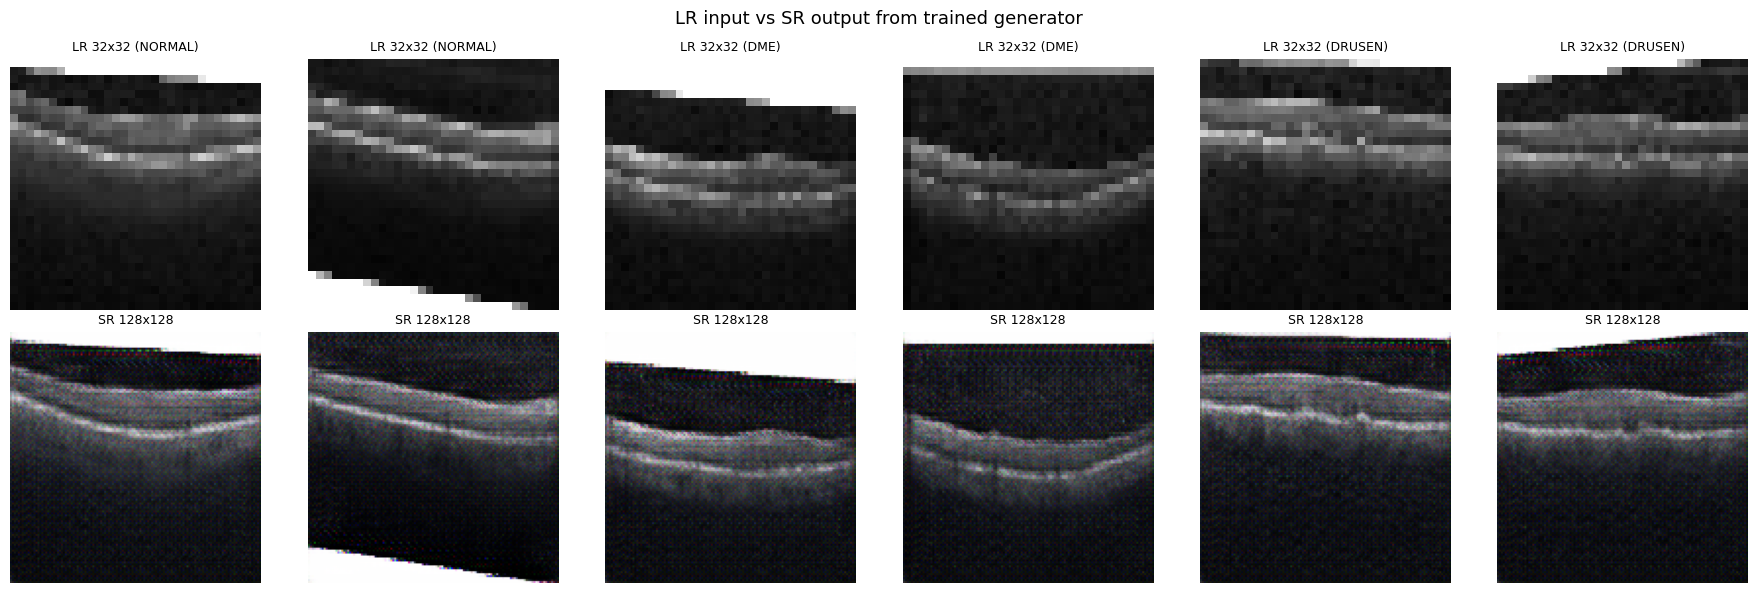

In [61]:
# 2 test images per class
from PIL import Image as PILImage

# get sample files
sample_paths = []
for cls in classes:
    cls_dir = os.path.join(DATASET_PATH, "test", cls)
    fnames  = [f for f in os.listdir(cls_dir)
               if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff"))][:2]
    sample_paths += [os.path.join(cls_dir, f) for f in fnames]

# make a 2-row figure
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for i, path in enumerate(sample_paths[:6]):
    # load one test image
    img = np.array(PILImage.open(path).convert("RGB")).astype(np.float32)
    img = tf.constant(img)
    # make HR, LR, and SR versions
    hr  = tf.image.resize(img, [HR_SIZE, HR_SIZE]) / 127.5 - 1.0
    lr  = (tf.image.resize(hr, [LR_SIZE, LR_SIZE]) + 1.0) / 2.0
    sr  = generator(tf.expand_dims(lr, 0), training=False)[0]

    # convert for display
    lr_disp = lr.numpy()
    sr_disp = np.clip((sr.numpy() + 1.0) / 2.0, 0, 1)
    cls_label = os.path.basename(os.path.dirname(path))

    # top row = LR input
    axes[0, i].imshow(lr_disp)
    axes[0, i].set_title(f"LR {LR_SIZE}x{LR_SIZE} ({cls_label})", fontsize=9)
    axes[0, i].axis("off")

    # bottom row = SR output
    axes[1, i].imshow(sr_disp)
    axes[1, i].set_title(f"SR {HR_SIZE}x{HR_SIZE}", fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("LR input vs SR output from trained generator", fontsize=13)
plt.tight_layout()
plt.show()

## Build New Dataset
Generate SR training images and save them by class.

In [62]:
# keep the same folder layout
SR_DATASET_PATH = "/content/drive/MyDrive/SR_Dataset"
os.makedirs(SR_DATASET_PATH, exist_ok=True)

# save each class in its own folder
for cls in classes:
    src_dir  = os.path.join(DATASET_PATH, "train", cls)
    save_dir = os.path.join(SR_DATASET_PATH, cls)
    os.makedirs(save_dir, exist_ok=True)

    # get all train images in this class
    fnames = [f for f in os.listdir(src_dir)
              if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff"))]
    print(f"{cls}: {len(fnames)} images...")

    # make and save one SR image
    for fname in fnames:
        save_path = os.path.join(save_dir, fname.rsplit(".", 1)[0] + "_sr.png")
        if os.path.exists(save_path):
            continue  # skip if saved

        # build HR, LR, and SR
        img = np.array(PILImage.open(os.path.join(src_dir, fname)).convert("RGB")).astype(np.float32)
        img = tf.constant(img)
        hr  = tf.image.resize(img, [HR_SIZE, HR_SIZE]) / 127.5 - 1.0
        lr  = (tf.image.resize(hr, [LR_SIZE, LR_SIZE]) + 1.0) / 2.0
        sr  = generator(tf.expand_dims(lr, 0), training=False)[0]

        # save the SR image
        sr_uint8 = tf.cast(tf.clip_by_value((sr + 1.0) / 2.0 * 255.0, 0, 255), tf.uint8)
        tf.keras.utils.save_img(save_path, sr_uint8.numpy())

print("SR dataset built")

NORMAL: 970 images...
DME: 796 images...
DRUSEN: 502 images...
SR dataset built


## Train Model B
Train the Assignment 1 classifier on the SR dataset.

In [63]:
# same setup as Assignment 1, but use SR images
sr_gen_maker = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

# training split
sr_train_gen = sr_gen_maker.flow_from_directory(
    SR_DATASET_PATH,
    target_size=img_size, batch_size=batch_size, classes=classes,
    class_mode="categorical", color_mode="rgb", subset="training", shuffle=True
)

# validation split
sr_val_gen = sr_gen_maker.flow_from_directory(
    SR_DATASET_PATH,
    target_size=img_size, batch_size=batch_size, classes=classes,
    class_mode="categorical", color_mode="rgb", subset="validation", shuffle=True
)

# use MobileNetV2 as the base
base_b = tf.keras.applications.MobileNetV2(
    input_shape=(img_size[0], img_size[1], 3), include_top=False, weights="imagenet"
)
base_b.trainable = False

# small classifier head
model_b = tf.keras.Sequential([
    base_b,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(classes), activation="softmax")
])

# compile Model B
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_b.summary()

Found 1815 images belonging to 3 classes.
Found 453 images belonging to 3 classes.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [64]:
# resume Model B if checkpoints exist
mb_ckpts = sorted(glob.glob(os.path.join(SAVE_DIR, "model_b_epoch_*.keras")))

history_b = None  # start empty

if mb_ckpts:
    latest = mb_ckpts[-1]
    start_epoch = int(os.path.basename(latest).replace("model_b_epoch_", "").replace(".keras", ""))
    model_b = tf.keras.models.load_model(latest)
    print(f"resuming model B from epoch {start_epoch + 1} (loaded epoch {start_epoch})")
else:
    start_epoch = 0
    print("starting model B from scratch")

# save checkpoints and stop early
callbacks_b = [
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(SAVE_DIR, "model_b_epoch_{epoch:03d}.keras"),
        save_freq="epoch"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True
    )
]

# train if not finished
if start_epoch < 150:
    history_b = model_b.fit(
        sr_train_gen, validation_data=sr_val_gen,
        epochs=150, initial_epoch=start_epoch,
        callbacks=callbacks_b
    )
else:
    print("model B already complete, skipping")

resuming model B from epoch 145 (loaded epoch 144)
Epoch 145/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 33s 430ms/step - accuracy: 0.9691 - loss: 0.0852 - val_accuracy: 0.8609 - val_loss: 0.3703
Epoch 146/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 234ms/step - accuracy: 0.9780 - loss: 0.0756 - val_accuracy: 0.8631 - val_loss: 0.3514
Epoch 147/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 238ms/step - accuracy: 0.9708 - loss: 0.0934 - val_accuracy: 0.8499 - val_loss: 0.3844
Epoch 148/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 237ms/step - accuracy: 0.9642 - loss: 0.0914 - val_accuracy: 0.8411 - val_loss: 0.4314
Epoch 149/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 233ms/step - accuracy: 0.9713 - loss: 0.0907 - val_accuracy: 0.8675 - val_loss: 0.3615
Epoch 150/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 233ms/step - accuracy: 0.9647 - loss: 0.0952 - val_accuracy: 0.8543 - val_loss: 0.4153


## Model B Graphs
Show training curves and test results.

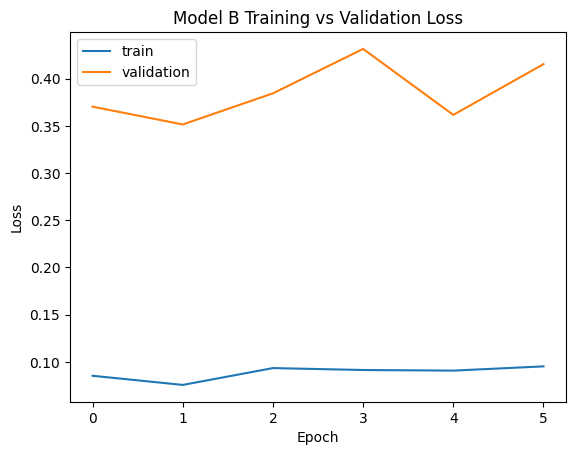

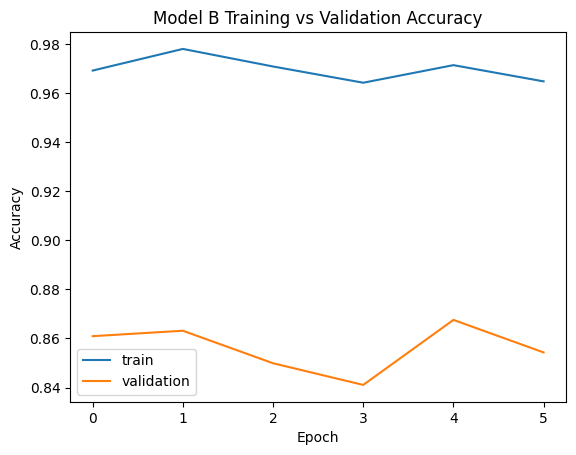

31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 239ms/step
Model B Results:
              precision    recall  f1-score   support

      NORMAL       0.87      0.70      0.77       437
         DME       0.65      0.89      0.75       305
      DRUSEN       0.74      0.65      0.69       221

    accuracy                           0.75       963
   macro avg       0.75      0.74      0.74       963
weighted avg       0.77      0.75      0.75       963



In [65]:
# plot curves only if this session trained
if history_b is not None:
    # loss curve
    plt.figure()
    plt.plot(history_b.history["loss"])
    plt.plot(history_b.history["val_loss"])
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Model B Training vs Validation Loss")
    plt.legend(["train", "validation"])
    plt.show()

    # accuracy curve
    plt.figure()
    plt.plot(history_b.history["accuracy"])
    plt.plot(history_b.history["val_accuracy"])
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Model B Training vs Validation Accuracy")
    plt.legend(["train", "validation"])
    plt.show()

# reset and test on the same images as Model A
test_gen.reset()
# predictions for Model B
probs_b  = model_b.predict(test_gen)
y_pred_b = np.argmax(probs_b, axis=1)

print("Model B Results:")
print(classification_report(y_true, y_pred_b, target_names=classes))

## Model A vs Model B
Compare F1, accuracy, and AUC.

Metric               Model A      Model B
-----------------------------------------
F1 (weighted)         0.8623       0.7470
Accuracy              0.8660       0.7466
AUC (OvR)             0.9797       0.9189


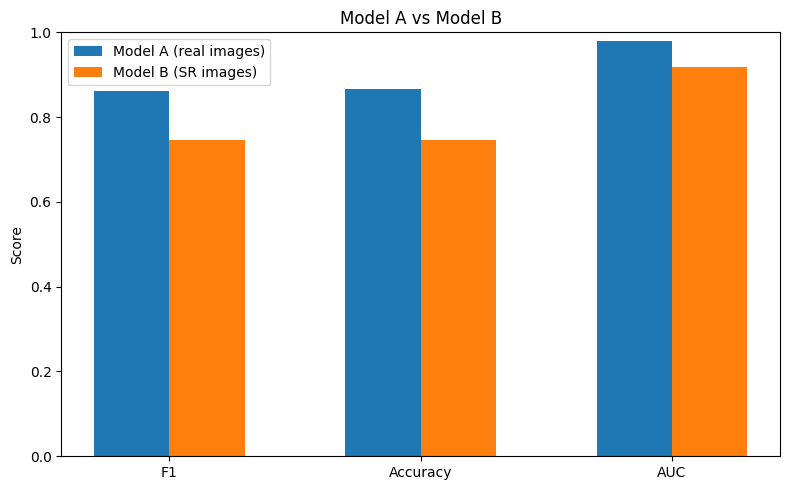

In [66]:
# compare both models
f1_a  = f1_score(y_true, y_pred_a, average="weighted")
f1_b  = f1_score(y_true, y_pred_b, average="weighted")
acc_a = accuracy_score(y_true, y_pred_a)
acc_b = accuracy_score(y_true, y_pred_b)
auc_a = roc_auc_score(y_true, probs_a, multi_class="ovr", average="weighted")
auc_b = roc_auc_score(y_true, probs_b, multi_class="ovr", average="weighted")

# print a small table
print(f"{'Metric':<15} {'Model A':>12} {'Model B':>12}")
print("-" * 41)
print(f"{'F1 (weighted)':<15} {f1_a:>12.4f} {f1_b:>12.4f}")
print(f"{'Accuracy':<15} {acc_a:>12.4f} {acc_b:>12.4f}")
print(f"{'AUC (OvR)':<15} {auc_a:>12.4f} {auc_b:>12.4f}")

# data for the bar chart
metrics  = ["F1", "Accuracy", "AUC"]
scores_a = [f1_a, acc_a, auc_a]
scores_b = [f1_b, acc_b, auc_b]
x = np.arange(len(metrics))
w = 0.3

# plot Model A vs Model B
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, scores_a, w, label="Model A (real images)")
ax.bar(x + w/2, scores_b, w, label="Model B (SR images)")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model A vs Model B")
ax.legend()
plt.tight_layout()
plt.show()